# Pemodelan Konsumsi Bahan Bakar Kendaraan Menggunakan Regresi Polinomial Bertingkat dengan Seleksi Fitur Berbasis Korelasi

**Info Ngopi**

| Anggota | NIM |
|---|---|
| Amadeus Eugene Dirgantara | 0706012410063 |
| Rei Putra Soemanto | 0706012410060 |
| Jason Tio | 0706012410006 |

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.float_format', lambda v: f'{v:.4f}')
sns.set_theme(style='whitegrid', context='notebook')
RNG = 42

## Exploratory Data Analysis dan Preliminary Analysis

### 1. Memuat Data Mentah

In [73]:
raw = pd.read_csv('dataset/Fuel_Consumption_2000-2022.csv')
print('Bentuk:', raw.shape)
raw.head()

Bentuk: (22556, 13)


,YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,HWY (L/100 km),COMB (L/100 km),COMB (mpg),EMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6000,4,A4,X,9.2000,6.7000,8.1000,35,186
1,2000,ACURA,1.6EL,COMPACT,1.6000,4,M5,X,8.5000,6.5000,7.6000,37,175
2,2000,ACURA,3.2TL,MID-SIZE,3.2000,6,AS5,Z,12.2000,7.4000,10.0000,28,230
3,2000,ACURA,3.5RL,MID-SIZE,3.5000,6,A4,Z,13.4000,9.2000,11.5000,25,264
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8000,4,A4,X,10.0000,7.0000,8.6000,33,198


In [74]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22556 entries, 0 to 22555
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   YEAR              22556 non-null  int64  
 1   MAKE              22556 non-null  object 
 2   MODEL             22556 non-null  object 
 3   VEHICLE CLASS     22556 non-null  object 
 4   ENGINE SIZE       22556 non-null  float64
 5   CYLINDERS         22556 non-null  int64  
 6   TRANSMISSION      22556 non-null  object 
 7   FUEL              22556 non-null  object 
 8   FUEL CONSUMPTION  22556 non-null  float64
 9   HWY (L/100 km)    22556 non-null  float64
 10  COMB (L/100 km)   22556 non-null  float64
 11  COMB (mpg)        22556 non-null  int64  
 12  EMISSIONS         22556 non-null  int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 2.2+ MB


### 2. Memeriksa Nilai yang Hilang

In [75]:
missing = raw.isna().sum().to_frame('n_missing')
missing

,n_missing
YEAR,0
MAKE,0
MODEL,0
VEHICLE CLASS,0
ENGINE SIZE,0
CYLINDERS,0
TRANSMISSION,0
FUEL,0
FUEL CONSUMPTION,0
HWY (L/100 km),0


*Tidak ditemukan nilai yang hilang di dataset.*

### 3. Memeriksa Data Duplikat

In [76]:
n_before = len(raw)
raw = raw.drop_duplicates().reset_index(drop=True)
print(f'Menghapus {n_before - len(raw)} baris duplikat. Tersisa: {len(raw)}')

Menghapus 1 baris duplikat. Tersisa: 22555


### 4. Inspeksi Kolom Transmisi

In [77]:
print('Jumlah kategori transmisi:', raw['TRANSMISSION'].nunique())
print('Nilai unik:', sorted(raw['TRANSMISSION'].unique()))
raw['TRANSMISSION'].value_counts()

Jumlah kategori transmisi: 30
Nilai unik: ['A10', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'AM5', 'AM6', 'AM7', 'AM8', 'AM9', 'AS10', 'AS4', 'AS5', 'AS6', 'AS7', 'AS8', 'AS9', 'AV', 'AV1', 'AV10', 'AV6', 'AV7', 'AV8', 'M4', 'M5', 'M6', 'M7']


TRANSMISSION
A4      3518
AS6     2834
M6      2609
M5      2104
A6      1965
AS8     1733
A5      1420
AS5      865
AV       816
A8       794
AM7      689
AS7      614
A9       529
AS10     335
A7       278
AS4      245
AM6      214
AM8      164
A10      162
AV7      143
AV6      137
M7       130
AS9      110
AV8       78
AV10      25
A3        24
AV1        8
AM5        6
AM9        5
M4         1
Name: count, dtype: int64

*Seperti yang tertulis di proposal, `transmission` awalnya merupakan sebagai salah satu kandidat variabel prediktor. Kolom `TRANSMISSION` ternyata berisi kode kategorikal seperti `A4`, `A5`, `M5`, `M6`, `AS6`, `AV`, dan seterusnya, yang menandai tipe sekaligus jumlah gigi transmisi (otomatis, manual, CVT, dan varian lainnya). Karena nilainya bersifat kategorikal nominal dan bukan rasio, kolom `TRANSMISSION` tidak bisa digunakan dalam analisis korelasi maupun regresi polinomial dan lebih cocok untuk model ensemble. Oleh karena itu, `transmission` dikeluarkan dari himpunan kandidat, dan frame analisis hanya dibangun dari variabel prediktor numerik kontinu `engine_size`, `cylinders`, dan `year`.*

### 5. Membangun Frame Analisis

In [78]:
df = raw[['ENGINE SIZE', 'CYLINDERS', 'YEAR', 'COMB (L/100 km)']].rename(
    columns={
        'ENGINE SIZE': 'engine_size',
        'CYLINDERS': 'cylinders',
        'YEAR': 'year',
        'COMB (L/100 km)': 'comb_l_100km',
    }
).reset_index(drop=True)
df.head()

,engine_size,cylinders,year,comb_l_100km
0,1.6000,4,2000,8.1000
1,1.6000,4,2000,7.6000
2,3.2000,6,2000,10.0000
3,3.5000,6,2000,11.5000
4,1.8000,4,2000,8.6000


### 6. Statistik Deskriptif

In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine_size,22555.0000,3.3566,1.3354,0.8000,2.3000,3.0000,4.2000,8.4000
cylinders,22555.0000,5.8540,1.8196,2.0000,4.0000,6.0000,8.0000,16.0000
year,22555.0000,2011.5550,6.2979,2000.0000,2006.0000,2012.0000,2017.0000,2022.0000
comb_l_100km,22555.0000,11.0341,2.9108,3.6000,9.1000,10.6000,12.7000,26.1000


*`engine_size` berkisar antara 1 sampai 8 L dengan median di sekitar 3 L, `cylinders` terkonsentrasi pada nilai 4/6/8, dan `year` mencakup 2000 sampai 2022 secara merata. Mayoritas `comb_l_100km` mobil berada di rentang 8 sampai 14 L/100 km dan ekor yang lebih tipis setelah kisaran 20 L/100 km.*

### 7. Pair Plot

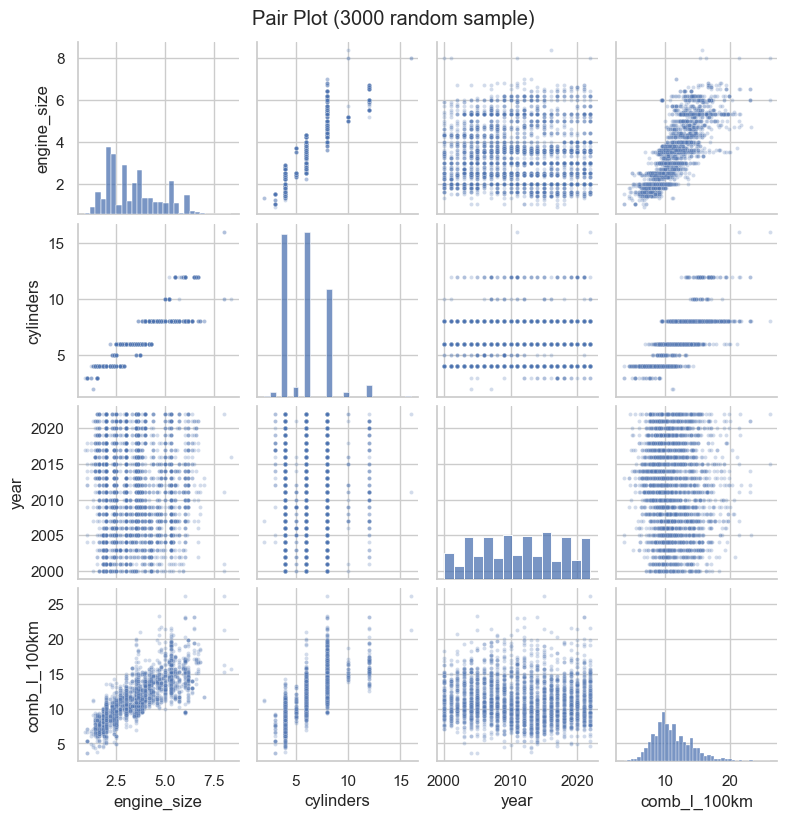

In [80]:
sample = df.sample(n=min(3000, len(df)), random_state=RNG)
sns.pairplot(sample, plot_kws={'alpha': 0.25, 's': 8}, diag_kind='hist', height=2.0)
plt.suptitle('Pair Plot (3000 random sample)', y=1.02)
plt.show()

***Histogram Plot (diagonal):***
- *`engine_size` dan `comb_l_100km` berbentuk right-skewed dengan ekor atas panjang, kemungkinan dari kendaraan mewah atau kendaraan berperforma tinggi.*
- *`cylinders` terdistribusi secara diskret dan terkonsentrasi pada nilai 4/6/8 silinder, sehingga hanya tampak sebagai beberapa batang terpisah.*
- *`year` terdistribusi secara merata karena jumlah sampel dari tahun ke tahun relatif seimbang.*

***Scatter Plot (off-diagonal):***
- *`engine_size` vs `comb_l_100km`: monotonik, jelas, melandai setelah sekitar 5L/100km. Ini mengindikasikan asosiasi non-linear.*
- *`cylinders` vs `comb_l_100km`: monotonik, cukup jelas walaupun diskret, dan juga ada pola melandai sekitar setelah sekitar 8 silinder.*
- *`engine_size` vs `cylinders`: monotonik, jelas, nyaris linear. Ini mengindikasikan multikolinearitas sehingga kedua variabel prediktor tidak bisa digunakan sebagai fitur secara bersamaan, harus memilih salah satu.*
- *`year` vs `comb_l_100km`, `year` vs `engine_size`, dan `year` vs `cylinders`:: tidak terlihat struktur yang jelas. Ini mengindikasikan bahwa kedua variabel tidak terkorelasi sama sekali.*

### 8. Matriks Korelasi Pearson

Korelasi Pearson menangkap asosiasi linear.

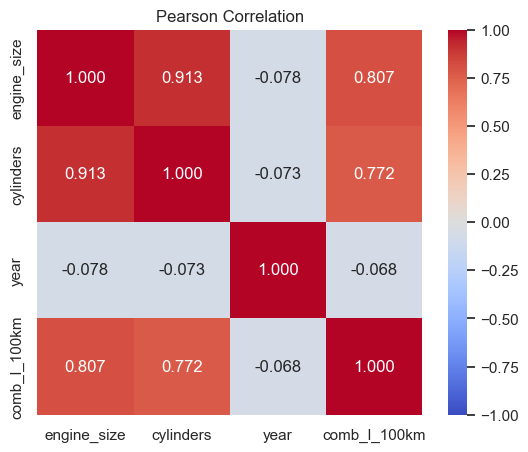

,engine_size,cylinders,year,comb_l_100km
engine_size,1.0000,0.9134,-0.0777,0.8073
cylinders,0.9134,1.0000,-0.0725,0.7716
year,-0.0777,-0.0725,1.0000,-0.0679
comb_l_100km,0.8073,0.7716,-0.0679,1.0000


In [81]:
pearson = df.corr(method='pearson')
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(pearson, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Pearson Correlation')
plt.show()
pearson

In [82]:
cols = df.columns.tolist()
pearson_p = pd.DataFrame(np.nan, index=cols, columns=cols)
for c1 in cols:
    for c2 in cols:
        if c1 != c2:
            _, p = stats.pearsonr(df[c1], df[c2])
            pearson_p.loc[c1, c2] = p
print('Pearson Correlation p-values')
pearson_p

Pearson Correlation p-values


,engine_size,cylinders,year,comb_l_100km
engine_size,NaN,0.0000,0.0000,0.0000
cylinders,0.0000,NaN,0.0000,0.0000
year,0.0000,0.0000,NaN,0.0000
comb_l_100km,0.0000,0.0000,0.0000,NaN


**Korelasi linear dengan `comb_l_100km`**
- *`engine_size` memiliki korelasi paling kuat (Pearson r ≈ 0.81), kemudian `cylinders` (r ≈ 0.77).*
- *`year` tidak memiliki korelasi signifikan (|r| < 0.08), sehingga tidak berguna sebagai fitur model.*

**p-value: signifikan secara statistik**
- *Semua p-value Pearson ≈ 0 (p < 1e-15), artinya nilai korelasi di atas dapat diandalkan.*

**Multikolinieritas antar variabel prediktor**
- *`engine_size` dan `cylinders` memiliki korelasi yang sangat tinggi (r ≈ 0.91) sehingga kedua variabel tidak bisa digunakan sebagai fitur secara bersamaan.*

### 9. Matriks Korelasi Spearman

Korelasi Spearman menangkap asosiasi monotonik.

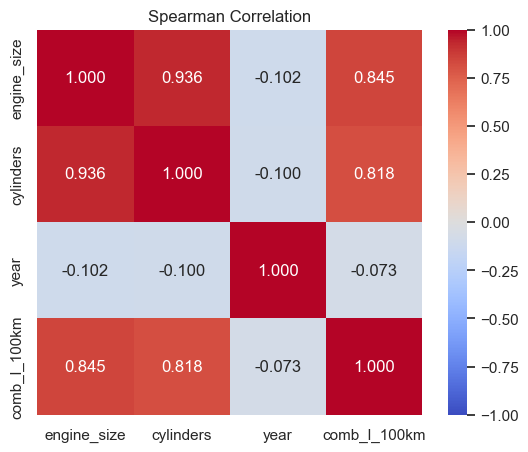

,engine_size,cylinders,year,comb_l_100km
engine_size,1.0000,0.9357,-0.1020,0.8449
cylinders,0.9357,1.0000,-0.0998,0.8176
year,-0.1020,-0.0998,1.0000,-0.0732
comb_l_100km,0.8449,0.8176,-0.0732,1.0000


In [83]:
spearman = df.corr(method='spearman')
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(spearman, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Spearman Correlation')
plt.show()
spearman

In [84]:
spearman_p = pd.DataFrame(np.nan, index=cols, columns=cols)
for c1 in cols:
    for c2 in cols:
        if c1 != c2:
            _, p = stats.spearmanr(df[c1], df[c2])
            spearman_p.loc[c1, c2] = p
print('Spearman Correlation p-values')
spearman_p

Spearman Correlation p-values


,engine_size,cylinders,year,comb_l_100km
engine_size,NaN,0.0000,0.0000,0.0000
cylinders,0.0000,NaN,0.0000,0.0000
year,0.0000,0.0000,NaN,0.0000
comb_l_100km,0.0000,0.0000,0.0000,NaN


***Asosiasi monotonik dengan `comb_l_100km`***
- *`engine_size` memiliki asosiasi monotonik paling kuat (Spearman ρ ≈ 0.84), disusul `cylinders` (ρ ≈ 0.82). 
- *`year` tidak memiliki korelasi signifikan (|ρ| < 0.08), sehingga tidak berguna sebagai fitur model.*

***p-value Spearman***
- *Semua p-value Spearman ≈ 0 (p < 1e-15), artinya nilai korelasi di atas dapat diandalkan.*

In [85]:
target = 'comb_l_100km'
gap = pd.DataFrame({
    'pearson_vs_y':   pearson[target].drop(target),
    'pearson_p_vs_y': pearson_p[target].drop(target),
    'spearman_vs_y':  spearman[target].drop(target),
    'spearman_p_vs_y': spearman_p[target].drop(target),
})
gap['abs_gap'] = gap['spearman_vs_y'].abs() - gap['pearson_vs_y'].abs()
gap.sort_values('abs_gap', ascending=False)

,pearson_vs_y,pearson_p_vs_y,spearman_vs_y,spearman_p_vs_y,abs_gap
cylinders,0.7716,0.0000,0.8176,0.0000,0.0460
engine_size,0.8073,0.0000,0.8449,0.0000,0.0376
year,-0.0679,0.0000,-0.0732,0.0000,0.0053


**Pearson vs Spearman: deteksi non-linearitas monotonik**
- *Pearson menangkap hubungan linear, Spearman menangkap hubungan monotonik. Selisih ρ − r yang positif (kolom `abs_gap` di atas) menandakan hubungan monotonik tetapi tidak linear.*
- *`engine_size` dan `cylinders` punya ρ > r (selisih > ~0.02, nyata pada n ini), menguatkan kelengkungan yang terlihat di plot scatter dan memotivasi perluasan polinomial. Selisih `year` ≈ 0.*

### 10. Tahap 1: Keputusan Pemilihan Fitur

**Aturan.** Buang sebuah kandidat prediktor jika memenuhi salah satu dari berikut:
- (a) Korelasinya dengan `comb_l_100km` tidak signifikan pada α = 0.05 (p > 0.05 pada Pearson maupun Spearman). Pada n ≈ 20k hampir semua korelasi signifikan, jadi ini hanya pemeriksaan awal, bukan filter utama.
- (b) Korelasi marginalnya lemah secara praktis (|ρ| < ~0.20 pada Pearson maupun Spearman).
- (c) Hampir kolinier dengan prediktor lain yang dipertahankan (|ρ| > ~0.85 terhadap prediktor yang hubungannya dengan respons lebih kuat).

In [86]:
candidates = ['engine_size', 'cylinders', 'year']
rows = []
for pred in candidates:
    pear_y  = pearson.loc[pred, target]
    pear_p  = pearson_p.loc[pred, target]
    spear_y = spearman.loc[pred, target]
    spear_p = spearman_p.loc[pred, target]
    others  = [c for c in candidates if c != pred]
    max_partner = max(others, key=lambda c: abs(pearson.loc[pred, c]))
    max_val = pearson.loc[pred, max_partner]

    insignificant = pear_p > 0.05 and spear_p > 0.05
    weak      = abs(pear_y) < 0.20 and abs(spear_y) < 0.20
    collinear = abs(max_val) > 0.85

    if insignificant:
        decision = f'BUANG: tidak signifikan (Pearson p={pear_p:.3g}, Spearman p={spear_p:.3g})'
    elif weak:
        decision = 'BUANG: korelasi marginal lemah dengan y'
    elif collinear:
        peer_strength = abs(pearson.loc[max_partner, target])
        if peer_strength > abs(pear_y):
            decision = f'BUANG: kolinier dengan {max_partner} (r={max_val:.2f}), peer lebih kuat terkait dengan y'
        else:
            decision = f'PERTAHANKAN: kolinier dengan {max_partner} namun lebih kuat terkait dengan y'
    else:
        decision = 'PERTAHANKAN'
    rows.append({
        'predictor':     pred,
        'pearson_vs_y':  round(pear_y,  3),
        'pearson_p':     round(pear_p,  4),
        'spearman_vs_y': round(spear_y, 3),
        'spearman_p':    round(spear_p, 4),
        'strongest_peer': max_partner,
        'r_with_peer':   round(max_val, 3),
        'decision':      decision,
    })
selection = pd.DataFrame(rows)
selection

,predictor,pearson_vs_y,pearson_p,spearman_vs_y,spearman_p,strongest_peer,r_with_peer,decision
0,engine_size,0.8070,0.0000,0.8450,0.0000,cylinders,0.9130,PERTAHANKAN: kolinier dengan cylinders namun l...
1,cylinders,0.7720,0.0000,0.8180,0.0000,engine_size,0.9130,"BUANG: kolinier dengan engine_size (r=0.91), p..."
2,year,-0.0680,0.0000,-0.0730,0.0000,engine_size,-0.0780,BUANG: korelasi marginal lemah dengan y


- *Tabel ini menerapkan aturan di atas secara otomatis pada setiap kandidat; kolom `decision` mendokumentasikan alasan tiap keputusan agar dapat diaudit.*
- *Hasilnya: `cylinders` dan `year` dibuang, sehingga hanya `engine_size` yang dipertahankan.*

In [87]:
retained = selection.loc[selection['decision'].str.startswith('PERTAHANKAN'), 'predictor'].tolist()
print('Variabel Prediktor yang dipertahankan:', retained)
print('Variabel Respons:', target)

Variabel Prediktor yang dipertahankan: ['engine_size']
Variabel Respons: comb_l_100km


*Apa pun yang muncul di `retained` adalah persis himpunan kolom yang akan dikonsumsi oleh notebook regresi. Karena hanya `engine_size` yang tersisa, analisis menyusut menjadi regresi polinomial dengan satu variabel prediktor, dan matriks Z untuk variabel prediktor linear tambahan pada M₁, M₂, dan M₃ menjadi kosong. Dalam kasus tersebut, model menyederhana menjadi y = β₀ + β₁x₁ + ε, y = β₀ + β₁x₁ + β₂x₁² + ε, dan y = β₀ + β₁x₁ + β₂x₁² + β₃x₁³ + ε.*

## Pemodelan Regresi

### 11. Train dan Test Split

Kita menggunakan pembagian 80/20. Subset pelatihan dipakai untuk fitting model dan untuk Nested F-Test; subset uji ditahan untuk pemeriksaan generalisasi pada Bab 18.

In [88]:
engine_var = 'engine_size'
other_predictors = [p for p in retained if p != engine_var]
print('Variabel Prediktor yang diperluas menjadi suku polinomial :', engine_var)
print('Variabel Prediktor lain yang masuk secara linear          :', other_predictors)

X_full = df[retained].copy()
y_full = df[target].copy()
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=RNG)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Variabel Prediktor yang diperluas menjadi suku polinomial : engine_size
Variabel Prediktor lain yang masuk secara linear          : []
Train: (18044, 1) Test: (4511, 1)


### 12. Fitting Tiga Kandidat Model

Ketiga model memakai himpunan variabel prediktor yang sama persis dan hanya berbeda pada bagaimana `engine_size` dimasukkan, yaitu linear, kuadratik, atau kubik. Kita membangun setiap matriks desain secara eksplisit agar struktur nested model menjadi tidak ambigu.

In [89]:
def design(X, degree):
    parts = {}
    for d in range(1, degree + 1):
        name = engine_var if d == 1 else f'{engine_var}_pow{d}'
        parts[name] = X[engine_var] ** d
    for p in other_predictors:
        parts[p] = X[p]
    Z = pd.DataFrame(parts, index=X.index)
    return sm.add_constant(Z, has_constant='add')

X1_train, X2_train, X3_train = design(X_train, 1), design(X_train, 2), design(X_train, 3)
X1_test,  X2_test,  X3_test  = design(X_test, 1),  design(X_test, 2),  design(X_test, 3)

m1 = sm.OLS(y_train, X1_train).fit()
m2 = sm.OLS(y_train, X2_train).fit()
m3 = sm.OLS(y_train, X3_train).fit()

summary_tbl = pd.DataFrame({
    'model': ['M1 linear', 'M2 kuadratik', 'M3 kubik'],
    'k (params)': [int(m1.df_model + 1), int(m2.df_model + 1), int(m3.df_model + 1)],
    'R^2': [m1.rsquared, m2.rsquared, m3.rsquared],
    'adj R^2': [m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
    'AIC': [m1.aic, m2.aic, m3.aic],
    'BIC': [m1.bic, m2.bic, m3.bic],
    'RSS': [(m1.resid ** 2).sum(), (m2.resid ** 2).sum(), (m3.resid ** 2).sum()],
})
summary_tbl

,model,k (params),R^2,adj R^2,AIC,BIC,RSS
0,M1 linear,2,0.6511,0.6511,70632.6064,70648.2075,52941.0732
1,M2 kuadratik,3,0.6565,0.6565,70353.7501,70377.1519,52123.4213
2,M3 kubik,4,0.6570,0.6569,70329.9216,70361.1239,52048.8642


*R² naik secara monoton seiring penambahan suku polinomial karena setiap penambahan bersarang hanya dapat menjelaskan lebih banyak variansi in-sample. Adjusted R² memberi penalti pada kompleksitas model dan merupakan ukuran cepat yang lebih jujur. AIC dan BIC melakukan hal serupa dengan bobot penalti yang berbeda; BIC memberi penalti lebih keras sehingga cenderung memilih model yang lebih kecil. Kolom RSS adalah angka yang akan dibandingkan langsung oleh Nested F-Test pada Tahap 2 dan 3. Cek waras yang berguna: jika lompatan RSS dari M₁ ke M₂ besar tetapi dari M₂ ke M₃ kecil, kita berharap Tahap 2 menolak H₀ dan Tahap 3 gagal menolak H₀.*

In [90]:
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:           comb_l_100km   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                 3.367e+04
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        19:11:33   Log-Likelihood:                -35314.
No. Observations:               18044   AIC:                         7.063e+04
Df Residuals:                   18042   BIC:                         7.065e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           5.1220      0.035    148.282      

*Ini adalah fit linear baseline. Koefisien dapat diinterpretasikan dalam satuan aslinya: kenaikan 1 L pada `engine_size` menggeser prediksi konsumsi sebesar β₁ L/100 km, dengan menahan variabel prediktor lain yang dipertahankan tetap konstan. Durbin-Watson statistic di bagian bawah memeriksa autokorelasi pada residu; karena baris diurutkan berdasarkan model mobil, maknanya terbatas di sini, namun nilai yang sangat jauh dari 2 layak diselidiki. Condition number menyoroti multikolinieritas yang lolos dari Tahap 1; nilai di bawah ~30 dianggap bersih.*

In [91]:
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:           comb_l_100km   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                 1.724e+04
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        19:11:33   Log-Likelihood:                -35174.
No. Observations:               18044   AIC:                         7.035e+04
Df Residuals:                   18041   BIC:                         7.038e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                3.7779      0.087  

*M₂ menambahkan `engine_size`². Jika koefisien suku linear tetap positif sementara koefisien suku kuadratiknya negatif dan signifikan, kurva yang di-fit berbentuk konkaf (naik tetapi melandai). Bentuk inilah pola diminishing returns yang diprediksi secara fisik. Condition number akan jauh lebih besar daripada M₁ karena `engine_size` dan kuadratnya berkorelasi sangat tinggi; ini bersifat mekanis dan bukan masalah model. Nested F-Test pada Tahap 2 menangani signifikansi gabungan secara benar bahkan ketika t-statistic individu pada suku polinomial yang kolinier menjadi noisy.*

In [92]:
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:           comb_l_100km   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                 1.152e+04
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        19:11:33   Log-Likelihood:                -35161.
No. Observations:               18044   AIC:                         7.033e+04
Df Residuals:                   18040   BIC:                         7.036e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                4.6243      0.188  

*M₃ menambahkan `engine_size`³. Koefisien kubik secara sendirian sulit ditafsirkan secara fisik karena tandanya menyampaikan informasi tentang turunan ketiga dari kurva yang di-fit, bukan sesuatu yang bermakna langsung. Yang penting adalah apakah suku tersebut mengurangi varians residu cukup banyak untuk membenarkan parameter ekstra. Pertanyaan itulah yang dijawab oleh Nested F-Test Tahap 3 pada subbagian berikutnya.*

### 13. Tahap 2: Nested F-Test, M₁ vs M₂

Kita menguji apakah penambahan suku `engine_size`² mengurangi varians residu secara berarti.

* **H₀:** β₂ = 0 (M₁ sudah memadai).
* **H₁:** β₂ ≠ 0 (M₂ diperlukan).

Tolak H₀ pada α = 0.05 jika p < 0.05.

In [93]:
anova_12 = anova_lm(m1, m2)
anova_12

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,18042.0000,52941.0732,0.0000,NaN,NaN,NaN
1,18041.0000,52123.4213,1.0000,817.6519,283.0063,0.0000


*Baris yang menarik adalah baris kedua. Baris itu menampilkan perubahan RSS, derajat kebebasan dari suku yang ditambahkan (yaitu 1), F statistic, dan p-value untuk H₀: β₂ = 0. P-value di bawah 0.05 menolak spesifikasi linear demi spesifikasi kuadratik. Mengingat kelengkungan yang terlihat pada plot scatter dan kesenjangan Pearson terhadap Spearman pada `engine_size`, kita memperkirakan uji ini akan menolak secara meyakinkan.*

In [94]:
p_12 = anova_12['Pr(>F)'].iloc[-1]
reject_12 = p_12 < 0.05
print(f'p-value (M1 vs M2): {p_12:.4g}')
print('Keputusan:', 'TOLAK H0, lanjut ke Tahap 3' if reject_12 else 'GAGAL TOLAK H0, M1 menjadi model final')

p-value (M1 vs M2): 5.022e-63
Keputusan: TOLAK H0, lanjut ke Tahap 3


### 14. Tahap 3: Nested F-Test, M₂ vs M₃ (kondisional)

Dijalankan hanya bila H₀ ditolak pada Tahap 2. Kita menguji apakah penambahan suku `engine_size`³ mengurangi varians residu lebih jauh.

* **H₀:** β₃ = 0 (M₂ sudah memadai).
* **H₁:** β₃ ≠ 0 (M₃ diperlukan).

In [95]:
if reject_12:
    anova_23 = anova_lm(m2, m3)
    print(anova_23)
    p_23 = anova_23['Pr(>F)'].iloc[-1]
    reject_23 = p_23 < 0.05
    final_label = 'M3 kubik' if reject_23 else 'M2 kuadratik'
    final_model = m3 if reject_23 else m2
    X_train_final = X3_train if reject_23 else X2_train
    X_test_final  = X3_test  if reject_23 else X2_test
    print(f'\np-value (M2 vs M3): {p_23:.4g}')
    print('Keputusan:', 'TOLAK H0, pilih M3 (kubik)' if reject_23 else 'GAGAL TOLAK H0, pilih M2 (kuadratik)')
else:
    final_label = 'M1 linear'
    final_model = m1
    X_train_final, X_test_final = X1_train, X1_test
    p_23 = None
    reject_23 = False
    print('Tahap 3 dilewati karena Tahap 2 sudah memilih M1.')

print('\nModel final:', final_label)

    df_resid        ssr  df_diff  ss_diff       F  Pr(>F)
0 18041.0000 52123.4213   0.0000      NaN     NaN     NaN
1 18040.0000 52048.8642   1.0000  74.5571 25.8413  0.0000



p-value (M2 vs M3): 3.744e-07
Keputusan: TOLAK H0, pilih M3 (kubik)

Model final: M3 kubik


*Jika dijalankan, sel ini meningkatkan model menjadi kubik atau berhenti di kuadratik. Model terpilih menjadi `final_model` dan matriks desainnya menjadi `X_train_final` dan `X_test_final`, yang dipakai oleh seluruh bab di bawah. 'Polinomial berorde terendah yang memodelkan hubungan secara memadai' ditetapkan di sini. Kerangka sequential test menjaga kita dari overfitting dengan menolak penambahan suku kecuali suku tersebut menghasilkan pengurangan varians residu yang signifikan secara statistik.*

### 15. Plot Scatter dengan Kurva Regresi Terpilih

Kita memplot `engine_size` terhadap `comb_l_100km` (data pelatihan) dan menumpangkan ketiga kurva polinomial yang sudah di-fit. Karena model bersifat multivariat, kita harus menetapkan variabel prediktor lain yang dipertahankan pada nilai referensi agar dapat menggambar kurva 2-D. Kita memakai rata rata himpunan pelatihan. Kurva yang berkaitan dengan model yang dipilih oleh Tahap 2 dan 3 digambar solid dan lebih tebal; alternatifnya digambar putus putus sebagai pembanding visual.

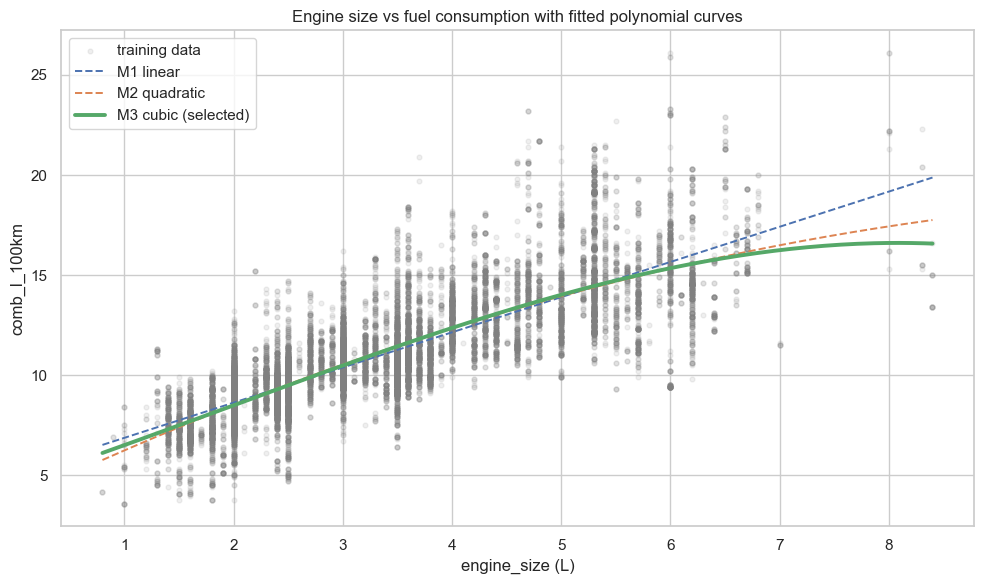

In [96]:
engine_grid = np.linspace(X_train[engine_var].min(), X_train[engine_var].max(), 200)
ref_means = {p: X_train[p].mean() for p in other_predictors}

def curve_design(degree):
    parts = {}
    for d in range(1, degree + 1):
        name = engine_var if d == 1 else f'{engine_var}_pow{d}'
        parts[name] = engine_grid ** d
    for p in other_predictors:
        parts[p] = np.full_like(engine_grid, ref_means[p], dtype=float)
    return sm.add_constant(pd.DataFrame(parts), has_constant='add')

curves = {
    'M1 linear':    m1.predict(curve_design(1)),
    'M2 quadratic': m2.predict(curve_design(2)),
    'M3 cubic':     m3.predict(curve_design(3)),
}

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_train[engine_var], y_train, alpha=0.12, s=12, color='gray', label='training data')
for label, yhat in curves.items():
    is_final_solid = (
        (label == 'M1 linear' and final_label == 'M1 linear') or
        (label == 'M2 quadratic' and final_label == 'M2 kuadratik') or
        (label == 'M3 cubic' and final_label == 'M3 kubik')
    )
    ax.plot(
        engine_grid, yhat,
        linewidth=2.8 if is_final_solid else 1.4,
        linestyle='-' if is_final_solid else '--',
        label=f'{label}{" (selected)" if is_final_solid else ""}',
    )

if other_predictors:
    ref_str = ', '.join(f'{p}={ref_means[p]:.2f}' for p in other_predictors)
    subtitle = f'\nother predictors fixed at training means ({ref_str})'
else:
    subtitle = ''
ax.set_xlabel(f'{engine_var} (L)')
ax.set_ylabel(target)
ax.set_title(f'Engine size vs fuel consumption with fitted polynomial curves{subtitle}')
ax.legend()
fig.tight_layout()
plt.show()

*Kurva terpilih (garis solid yang lebih tebal) seharusnya secara visual mengikuti pusat awan titik di sepanjang rentang `engine_size`. Ketidakcocokan yang tampak pada salah satu ekor akan menjadi pertanda awal pelanggaran asumsi OLS dalam residunya. Kurva putus putus memperlihatkan seberapa jauh orde polinomial yang ditolak berbeda dari yang dipilih. Perbedaan visual yang kecil menyiratkan Nested F-Test benar dengan memilih model yang lebih sederhana, sedangkan perbedaan besar antara M₁ dan M₂ misalnya, mengonfirmasi bahwa kelengkungan memang penting. Karena tidak ada variabel prediktor lain yang dipertahankan oleh Tahap 1, kurva memang merepresentasikan efek `engine_size` saja.*

## Validasi dan Evaluasi Model

### 16. Tahap 4: Validasi Asumsi pada Model Terpilih

Kita menguji normalitas residu (Anderson-Darling test) dan homoskedastisitas (Breusch-Pagan test), serta memasangkan keduanya dengan Q-Q plot dan plot residuals vs fitted. Pada n yang besar, bahkan deviasi kecil dari asumsi ini biasanya mencapai signifikansi statistik, sehingga kita melaporkan hasil uji dan diagnostik visual secara bersama.

In [97]:
resid = final_model.resid
fitted = final_model.fittedvalues

ad = stats.anderson(resid, dist='norm')
print('Anderson-Darling test untuk normalitas residu')
print(f'  statistic           : {ad.statistic:.4f}')
for sig, crit in zip(ad.significance_level, ad.critical_values):
    print(f'  nilai kritis pada {sig:.1f}% : {crit:.4f}')
print('  kesimpulan          :', 'residu menyimpang dari normalitas pada nilai kritis 5%' if ad.statistic > ad.critical_values[2] else 'residu konsisten dengan normalitas pada nilai kritis 5%')

Anderson-Darling test untuk normalitas residu
  statistic           : 149.9923
  nilai kritis pada 15.0% : 0.5760
  nilai kritis pada 10.0% : 0.6560
  nilai kritis pada 5.0% : 0.7870
  nilai kritis pada 2.5% : 0.9180
  nilai kritis pada 1.0% : 1.0920
  kesimpulan          : residu menyimpang dari normalitas pada nilai kritis 5%


*Pada ukuran sampel ini (n ≈ 20k), Anderson-Darling test sangat sensitif. Hampir setiap distribusi residu dunia nyata akan melebihi nilai kritis 5% karena uji ini memiliki daya yang cukup untuk mendeteksi penyimpangan mikroskopis dari normalitas. Penolakan formal di sini tidak membatalkan model; ia hanya menyatakan bahwa residu tidak persis Gaussian. Q-Q plot di bawah adalah pendamping yang tepat. Jika penyimpangan terkonsentrasi pada ekor sementara bagian tengah mengikuti garis 45°, teorema limit pusat tetap memberikan inferensi yang valid pada koefisien.*

In [98]:
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(resid, X_train_final)
print('Breusch-Pagan test untuk homoskedastisitas')
print(f'  LM statistic        : {bp_stat:.4f}')
print(f'  p-value LM          : {bp_p:.4g}')
print(f'  F statistic         : {bp_f:.4f}')
print(f'  p-value F           : {bp_fp:.4g}')
print('  kesimpulan          :', 'tolak homoskedastisitas (residu heteroskedastik)' if bp_p < 0.05 else 'gagal menolak homoskedastisitas')

Breusch-Pagan test untuk homoskedastisitas
  LM statistic        : 1414.3351
  p-value LM          : 2.283e-306
  F statistic         : 511.4275
  p-value F           : 5.304e-319
  kesimpulan          : tolak homoskedastisitas (residu heteroskedastik)


*Caveat ukuran sampel yang sama berlaku seperti pada Anderson-Darling test. Dengan n ≈ 20k, Breusch-Pagan test akan menandai bahkan heteroskedastisitas yang moderat. Plot residuals vs fitted di bawah adalah pemeriksaan yang substantif. Jika awan residu melebar secara visual (varians tumbuh bersama nilai prediksi), heteroskedastisitas memang nyata dan akan berdampak pada standard error serta confidence interval, namun tidak pada estimasi titik koefisien itu sendiri. Solusi standar bila ini penting untuk pemakaian hilir adalah refit dengan standard error yang konsisten terhadap heteroskedastisitas (HC3).*

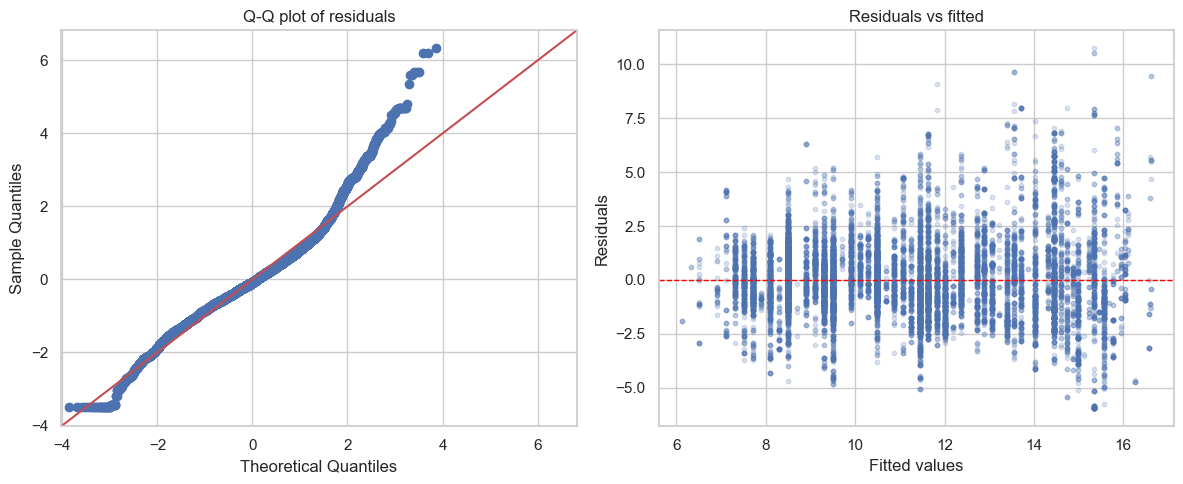

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sm.qqplot(resid, line='45', fit=True, ax=axes[0])
axes[0].set_title('Q-Q plot of residuals')

axes[1].scatter(fitted, resid, alpha=0.2, s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs fitted')

fig.tight_layout()
plt.show()

*Q-Q plot: titik yang dekat dengan garis 45° pada bagian tengah dengan penyimpangan hanya pada ekor sangat umum pada regresi terhadap data ekonomi/teknik yang memiliki skewness kanan, dan dapat diterima. Residuals vs fitted: pita horizontal di sekitar nol dengan lebar vertikal konstan adalah keadaan ideal. Kelengkungan sistematis pada plot ini (bentuk senyum atau muram) berarti orde polinomial yang dipilih keliru dan masih ada struktur yang terlewat. Bentuk yang melebar seperti corong mengonfirmasi heteroskedastisitas yang ditandai oleh Breusch-Pagan test. Bukti visualnyalah yang menentukan, bukan hasil uji formal.*

### 17. Evaluasi Generalisasi

Kita menghitung R², RMSE, dan MAE pada subset uji dan membandingkannya terhadap nilai pada subset pelatihan. Selisih pelatihan terhadap uji yang besar akan menandakan overfitting.

In [100]:
def metrics(y_true, y_pred):
    return {
        'R^2': r2_score(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': mean_absolute_error(y_true, y_pred),
    }

train_pred = final_model.predict(X_train_final)
test_pred = final_model.predict(X_test_final)

perf = pd.DataFrame({
    'train': metrics(y_train, train_pred),
    'test': metrics(y_test, test_pred),
})
perf['gap (train - test)'] = perf['train'] - perf['test']
perf

,train,test,gap (train - test)
R^2,0.6570,0.6582,-0.0012
RMSE,1.6984,1.7261,-0.0277
MAE,1.2440,1.2575,-0.0135


*Metrik pelatihan dan uji seharusnya dekat. Selisih positif yang besar (pelatihan jauh lebih baik daripada uji) menandai overfitting. Dengan ukuran sampel dalam ribuan dan hanya beberapa parameter, overfitting hampir pasti tidak terjadi. Kita memperkirakan selisih pada R² hanya sebagian kecil dari satu persen. RMSE berada dalam satuan asli variabel respons (L/100 km), sehingga langsung menjawab pertanyaan 'seberapa jauh rata rata sebuah prediksi meleset'. MAE kurang sensitif terhadap residu outlier dan berguna sebagai cek silang ketahanan.*

### 18. Pelaporan: Tabel Koefisien dan Tabel ANOVA untuk Model Final

In [101]:
conf = final_model.conf_int().rename(columns={0: 'CI_low_95', 1: 'CI_high_95'})
coef_table = pd.DataFrame({
    'coef': final_model.params,
    'std_err': final_model.bse,
    't': final_model.tvalues,
    'p_value': final_model.pvalues,
    'CI_low_95': conf['CI_low_95'],
    'CI_high_95': conf['CI_high_95'],
})
coef_table

,coef,std_err,t,p_value,CI_low_95,CI_high_95
const,4.6243,0.1878,24.6213,0.0000,4.2562,4.9925
engine_size,1.8027,0.1612,11.1853,0.0000,1.4868,2.1186
engine_size_pow2,0.1044,0.0425,2.4555,0.0141,0.0211,0.1878
engine_size_pow3,-0.0178,0.0035,-5.0834,0.0000,-0.0247,-0.0109


*Setiap baris memberi koefisien, standard error, t-statistic, p-value, dan confidence interval 95%. Koefisien yang CI-nya tidak melewati nol dapat dibedakan secara statistik dari nol. Koefisien polinomial pada `engine_size` semuanya akan sangat signifikan pada model terpilih; jika ada yang tidak, F-Test yang bersesuaian seharusnya sudah gagal dan suku tersebut tidak akan masuk model sejak awal. Intercept biasanya tidak dapat diinterpretasikan langsung ketika variabel prediktor tidak dipusatkan, karena merepresentasikan prediksi y pada `engine_size` = 0, suatu nilai di luar domain.*

In [102]:
anova_table = anova_lm(m1, m2, m3)
anova_table.index = ['M1 linear', 'M2 kuadratik', 'M3 kubik']
anova_table

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
M1 linear,18042.0000,52941.0732,0.0000,NaN,NaN,NaN
M2 kuadratik,18041.0000,52123.4213,1.0000,817.6519,283.3960,0.0000
M3 kubik,18040.0000,52048.8642,1.0000,74.5571,25.8413,0.0000


*Ini adalah ringkasan sequential test yang formal. Setiap baris memperlihatkan perubahan RSS saat berpindah dari satu model ke berikutnya beserta p-value untuk suku yang ditambahkan. Ini adalah format pelaporan kanonik untuk rangkaian keputusan Tahap 2 dan Tahap 3 (dua uji dalam satu tabel) dan akan menjadi bagian yang muncul dalam tulisan atau makalah sebagai bukti orde polinomial yang dipilih.*

## Kesimpulan

**A. (persiapan data dan Tahap 1).** 

Dataset Fuel Consumption 2000 sampai 2022 dimuat (22.556 baris, 13 kolom), diperiksa nilai hilangnya (tidak ada), lalu dibersihkan dari duplikat persis (1 baris dibuang sehingga tersisa 22.555). Tiga kandidat variabel prediktor kontinu dipertimbangkan, yaitu `engine_size`, `cylinders`, dan `year`, dengan variabel respons `comb_l_100km`. Statistik deskriptif, plot distribusi, plot scatter, serta matriks korelasi Pearson dan Spearman dihitung. Tahap 1 menerapkan aturan pemilihan fitur berbasis korelasi dan menyisakan satu variabel prediktor, yaitu `engine_size`. Variabel `cylinders` dibuang karena hampir kolinier dengan `engine_size` (r ≈ 0.91), sedangkan `year` dibuang karena korelasi marginalnya dengan variabel respons mendekati nol.

**B (pemodelan).** 

Data dibagi 80/20 menjadi subset pelatihan dan uji. Tiga model polinomial bersarang (linear, kuadratik, kubik) di-fit pada `engine_size`. Dua Nested F-Test sekuensial dijalankan, yaitu Tahap 2 (M₁ vs M₂) dan Tahap 3 (M₂ vs M₃). Asumsi OLS divalidasi dengan Anderson-Darling test, Breusch-Pagan test, Q-Q plot, dan plot residuals vs fitted. Performa generalisasi dievaluasi pada subset uji yang ditahan.

### Hasil

* **Model terpilih adalah M₃ (kubik).** Kedua Nested F-Test menolak H₀ secara meyakinkan (Tahap 2 p ≈ 5.0e-63, Tahap 3 p ≈ 3.7e-07), sehingga suku kuadratik dan kubik keduanya berkontribusi signifikan secara statistik. Bentuk kurva yang dihasilkan naik lalu melandai di sepanjang rentang `engine_size` yang teramati, konsisten dengan pola diminishing returns yang diprediksi secara fisik.
* **Daya penjelas tergolong moderat.** Model kubik mencapai R² ≈ 0.657 pada pelatihan dan R² ≈ 0.658 pada uji. Artinya `engine_size` sendirian menjelaskan sekitar 66% variansi konsumsi bahan bakar gabungan, sedangkan sisanya berasal dari faktor yang tidak dimodelkan seperti tipe bahan bakar, bobot, aerodinamika, dan drivetrain.
* **Tidak ada indikasi overfitting.** Selisih metrik pelatihan terhadap uji sangat kecil (R² berselisih sekitar 0.001 dan RMSE sekitar 0.03 L/100 km), sesuai harapan untuk model dengan sedikit parameter pada sampel besar.
* **Akurasi prediksi.** RMSE uji ≈ 1.73 L/100 km dan MAE uji ≈ 1.26 L/100 km, sehingga prediksi tipikal meleset sekitar 1.3 sampai 1.7 L/100 km dari nilai sebenarnya.
* **Asumsi OLS dilanggar secara formal namun tidak fatal.** Anderson-Darling test menolak normalitas dan Breusch-Pagan test menolak homoskedastisitas, keduanya merupakan konsekuensi wajar dari n yang besar. Estimasi titik koefisien tetap tidak bias; bila standard error dibutuhkan untuk inferensi presisi, refit dengan HC3 robust standard error adalah solusi standarnya.

### Keterbatasan

Model ini bersifat prediktif dan asosiatif, bukan kausal. Koefisien `engine_size` menyerap segala sesuatu yang berkorelasi dengannya tetapi tidak ikut dimodelkan, sehingga tidak boleh ditafsirkan sebagai efek kausal murni ukuran mesin terhadap konsumsi. Untuk pemakaian terapan (perencanaan armada, deteksi outlier, kebijakan pajak, perbandingan biaya konsumen, dan pelaporan keberlanjutan), R² ≈ 0.66 berarti prediksi berguna sebagai estimasi kasar namun masih menyisakan ketidakpastian per kendaraan yang cukup besar.

Sel di bawah merangkai kembali seluruh keputusan dan angka kunci ke dalam satu pembacaan tunggal.

In [103]:
print('=' * 64)
print('RINGKASAN ANALISIS REGRESI POLINOMIAL')
print('=' * 64)

print('\n[Persiapan data]')
print(f'  Baris setelah pembersihan       : {len(df)}')
print(f'  Variabel Respons                          : {target} (L/100 km)')

print('\n[Tahap 1: pemilihan fitur]')
print('  Kandidat                        : engine_size, cylinders, year')
print(f'  Dipertahankan                   : {retained}')
print('  Dibuang                         : cylinders (kolinier r~0.91), year (korelasi lemah)')

print('\n[Tahap 2 dan 3: Nested F-Test]')
print(f'  M1 vs M2 p-value                : {p_12:.4g}  -> {"tolak H0" if reject_12 else "gagal tolak H0"}')
if reject_12:
    print(f'  M2 vs M3 p-value                : {p_23:.4g}  -> {"tolak H0" if reject_23 else "gagal tolak H0"}')
else:
    print('  M2 vs M3                        : dilewati')
print(f'  Model final                     : {final_label}')

print('\n[Koefisien model final]')
for name, val in final_model.params.items():
    print(f'  {name:<24}        : {val:+.4f}')

print('\n[Tahap 4: validasi asumsi]')
ad_reject = ad.statistic > ad.critical_values[2]
print(f'  Anderson-Darling statistic      : {ad.statistic:.4f}  -> {"menyimpang dari normal" if ad_reject else "konsisten dengan normal"} (5%)')
print(f'  Breusch-Pagan p-value           : {bp_p:.4g}  -> {"heteroskedastik" if bp_p < 0.05 else "homoskedastik"}')

print('\n[Evaluasi generalisasi]')
print(f'  R^2  train / test               : {r2_score(y_train, train_pred):.4f} / {r2_score(y_test, test_pred):.4f}')
print(f'  RMSE train / test               : {np.sqrt(mean_squared_error(y_train, train_pred)):.4f} / {np.sqrt(mean_squared_error(y_test, test_pred)):.4f} L/100 km')
print(f'  MAE  train / test               : {mean_absolute_error(y_train, train_pred):.4f} / {mean_absolute_error(y_test, test_pred):.4f} L/100 km')
print('=' * 64)

RINGKASAN ANALISIS REGRESI POLINOMIAL

[Persiapan data]
  Baris setelah pembersihan       : 22555
  Variabel Respons                          : comb_l_100km (L/100 km)

[Tahap 1: pemilihan fitur]
  Kandidat                        : engine_size, cylinders, year
  Dipertahankan                   : ['engine_size']
  Dibuang                         : cylinders (kolinier r~0.91), year (korelasi lemah)

[Tahap 2 dan 3: Nested F-Test]
  M1 vs M2 p-value                : 5.022e-63  -> tolak H0
  M2 vs M3 p-value                : 3.744e-07  -> tolak H0
  Model final                     : M3 kubik

[Koefisien model final]
  const                           : +4.6243
  engine_size                     : +1.8027
  engine_size_pow2                : +0.1044
  engine_size_pow3                : -0.0178

[Tahap 4: validasi asumsi]
  Anderson-Darling statistic      : 149.9923  -> menyimpang dari normal (5%)
  Breusch-Pagan p-value           : 2.283e-306  -> heteroskedastik

[Evaluasi generalisasi]
  R^2  

*Readout di atas adalah rekap akhir yang dapat dibaca berdiri sendiri. Model final M₃ (kubik) dipilih oleh dua Nested F-Test, menjelaskan sekitar 66% variansi pada subset uji, dan tidak menunjukkan overfitting. Untuk klaim terapan, perlakukan prediksi sebagai estimasi kasar mengingat R² yang moderat dan asumsi homoskedastisitas yang dilanggar secara formal.*